In [1]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Imports for image transformations
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Importing Keras utility for image dataset loading
from keras.utils import image_dataset_from_directory

# Reporting t
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import helper
import importlib
importlib.reload(helper)

<module 'helper' from 'c:\\Users\\Thoma\\Downloads\\Python\\Github\\Covid-19_detection\\notebooks\\helper.py'>

In [3]:
# Variables and definitions
COVID_FOLDER = 'COVID-19_Radiography_Dataset'
#class_normal = 'normal'
#class_lung_opacity = 'lung_opacity'
#class_viral_pneumonia = 'viral_pneumonia'
#class_covid = 'covid'

### First try with Transfer Learning

##### Dataset loading and preprocessing

In [4]:
def read_xray_images(folder_path):
    batch_size = 16 # Rather small for fine grained learning rate
    input_shape = (224,224) # Resize it implicitely for our model

    # Load the dataset with validation split
    train_ds, val_ds = image_dataset_from_directory(
        folder_path,
        label_mode="int",      # for sparse_categorical_entropy training
        batch_size=batch_size,
        image_size=input_shape,
        validation_split=0.2,  # 20% for validation
        subset="both",         # Specify subset for training and validation to be created
        seed=42                # Ensure reproducibility
    )

    # Check, which class names found (should be our 4 (or less for trials)) and save it for later use
    class_names = train_ds.class_names.copy()
    print('Found classes:', class_names)

    # Optionally, you can cache and prefetch for performance
    train_ds = train_ds.cache().prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

    # Verify the datasets
    for images, labels in train_ds.take(1):
        print("Train dataset batch:", images.shape, labels.shape)
        print('Labels', labels.numpy())

    for images, labels in val_ds.take(1):
        print("Validation dataset batch:", images.shape, labels.shape)
        print('Labels', labels.numpy())

    return train_ds, val_ds, class_names

In [19]:
# Manually gather only the 'images' subfolders for each class
# in order to do this, we must temporarily move the masks away from the images
import shutil  # Stelle sicher, dass shutil importiert ist

TMP_FOLDER = 'tmp_' + str(np.random.randint(1e9))
MASK_FOLDER = 'masks'

# Parent folder
parent_folder = os.path.dirname(os.getcwd())
# COVID-19_Radiography_Dataset folder
folder_path = os.path.join(parent_folder, COVID_FOLDER)
tmp_folder_path = os.path.join(parent_folder, TMP_FOLDER)

# Prepare to move each masks subfolder temporarily away
folder_moves_dict = {os.path.join(folder_path, class_name, MASK_FOLDER):
                      os.path.join(parent_folder, TMP_FOLDER, class_name, MASK_FOLDER)
               for class_name in os.listdir(folder_path) 
               if os.path.isdir(os.path.join(folder_path, class_name, MASK_FOLDER))}

# Check if tmp-folder exists and create if not
tmp_exists = os.path.isdir(tmp_folder_path)
if False == tmp_exists:
   os.makedirs(tmp_folder_path, exist_ok=True)
   print(f"Created empty directory: {tmp_folder_path}")

# Move away the masks to tmp-folder
for move_from, move_to in folder_moves_dict.items():
   # Move the entire directory (actually by just renaming)
   os.makedirs(move_to, exist_ok=True)
   if os.path.exists(move_to):
      print(f"Skipping move: {move_to} already exists.")
      continue  # Überspringt das Umbenennen, wenn das Ziel existiert
   os.rename(move_from, move_to)
   print(f"Moved {move_from} to {move_to}")

# Read in the images
train_ds, val_ds, class_names = read_xray_images(folder_path)

# Move back the masks again and clean the tmp-folder
for move_to, move_from in folder_moves_dict.items(): # reverse order!
   # Move the entire directory
    if os.path.exists(move_to):
      print(f"Skipping move: {move_to} already exists.")
      continue  # Überspringt das Umbenennen, wenn das Ziel existiert
    os.rename(move_from, move_to)
    print(f"Moved {move_from} to {move_to}")

# If the tmp folder hasn't existed before, delete it again
if False == tmp_exists: # it hasn't existed before
   for dir in os.listdir(tmp_folder_path):
      if False == tmp_exists:  # it hasn't existed before
         shutil.rmtree(tmp_folder_path, ignore_errors=True)  # <-- sicher löschen, auch wenn nicht leer
         print(f"Deleted empty directory: {tmp_folder_path}")
      #os.rmdir(os.path.join(tmp_folder_path,dir))
   #os.rmdir(tmp_folder_path)
   #print(f"Deleted empty directory: {tmp_folder_path}")

Created empty directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_820906888
Skipping move: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_820906888\COVID\masks already exists.
Skipping move: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_820906888\Lung_Opacity\masks already exists.
Skipping move: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_820906888\Normal\masks already exists.
Skipping move: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_820906888\Viral Pneumonia\masks already exists.
Found 42330 files belonging to 4 classes.
Using 33864 files for training.
Using 8466 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (16, 224, 224, 3) (16,)
Labels [2 1 0 1 2 1 2 2 1 0 2 2 0 2 0 3]
Validation dataset batch: (16, 224, 224, 3) (16,)
Labels [2 2 2 2 1 1 2 2 1 0 0 2 2 1 0 2]
Skipping move: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detectio

In [20]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 2117
Number of batch in val_ds: 530
(16, 224, 224, 3) (16,)
(224, 224, 3) 3
(224, 224, 3) 2
(224, 224, 3) 3
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 0


In [21]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'COVID': 5765, 'Lung_Opacity': 9616, 'Normal': 16338, 'Viral Pneumonia': 2145}
Class Weights: {np.int32(0): 1.4685169124024284, np.int32(1): 0.8804076539101497, np.int32(2): 0.5181784796180683, np.int32(3): 3.946853146853147}


In [22]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

#### Try with VGG16 (imagenet pretrained)

In [23]:
# This model name for saving and loading
model_name = 'vgg16_' + str(len(class_names)) + '-classes.keras'

In [24]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16

# VGG16 model
base_model = VGG16(weights='imagenet', include_top=False)

# Freeze the layers of VGG16
base_model.trainable = False

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3))

# Apply augmentations
#x = RandomRotation(0.1)(inputs)
#x = RandomTranslation(height_factor=0.1, width_factor=0.1)(x)
#x = RandomZoom(0.1)(x)
#x = RandomFlip("horizontal")(x)

# Build the model
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

vgg16 = Model(inputs=inputs, outputs=outputs)

In [25]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=3, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 3 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [26]:
# Compile with first idea of appropriate parameters
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
vgg16.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
from helper import model_summary_to_df
df_summary = model_summary_to_df(vgg16)
display(df_summary)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,766,852 (60.15 MB)

 Trainable params: 1,052,164 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1 (InputLayer),"(None, 224, 224, 3)",0
1,vgg16 (Functional),"(None, 7, 7, 512)","14,714,688"
2,global_average_pooling2d,"(None, 512)",0
3,(GlobalAveragePooling2D),,
4,dense (Dense),"(None, 1024)","525,312"
5,dropout (Dropout),"(None, 1024)",0
6,dense_1 (Dense),"(None, 512)","524,800"
7,dropout_1 (Dropout),"(None, 512)",0
8,dense_2 (Dense),"(None, 4)","2,052"


In [27]:
# Train it with the entire dataset (takes very long!)
history_model = vgg16.fit(train_ds,
                          epochs=10,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[early_stopping, reduce_learning_rate])

# For a first quick evaluation, just read in a few batches instead of the entire dataset
#nr_batches = 16
#history_model = vgg16.fit(train_ds.shuffle(1000).take(nr_batches), 
#                          epochs=10,
#                          validation_data=val_ds.shuffle(1000).take(nr_batches),
#                          class_weight=class_weights_dict)

Epoch 1/10
2117/2117 ━━━━━━━━━━━━━━━━━━━━ 1068s 504ms/step - accuracy: 0.6361 - loss: 0.9258 - val_accuracy: 0.7674 - val_loss: 0.5998 - learning_rate: 0.0010
Epoch 2/10
2117/2117 ━━━━━━━━━━━━━━━━━━━━ 1064s 503ms/step - accuracy: 0.7465 - loss: 0.5360 - val_accuracy: 0.8018 - val_loss: 0.5185 - learning_rate: 0.0010
Epoch 3/10
2117/2117 ━━━━━━━━━━━━━━━━━━━━ 1071s 506ms/step - accuracy: 0.7691 - loss: 0.4950 - val_accuracy: 0.7942 - val_loss: 0.5316 - learning_rate: 0.0010
Epoch 4/10
2117/2117 ━━━━━━━━━━━━━━━━━━━━ 1117s 527ms/step - accuracy: 0.7820 - loss: 0.4734 - val_accuracy: 0.8066 - val_loss: 0.5029 - learning_rate: 0.0010
Epoch 5/10
2117/2117 ━━━━━━━━━━━━━━━━━━━━ 1095s 517ms/step - accuracy: 0.7902 - loss: 0.4607 - val_accuracy: 0.8083 - val_loss: 0.4990 - learning_rate: 0.0010
Epoch 6/10
2117/2117 ━━━━━━━━━━━━━━━━━━━━ 1082s 511ms/step - accuracy: 0.7853 - loss: 0.4578 - val_accuracy: 0.7973 - val_loss: 0.5110 - learning_rate: 0.0010
Epoch 7/10
2117/2117 ━━━━━━━━━━━━━━━━━━━━ 1020

In [28]:
# Save the model for potential later use
vgg16.save(model_name)

##### Evalution

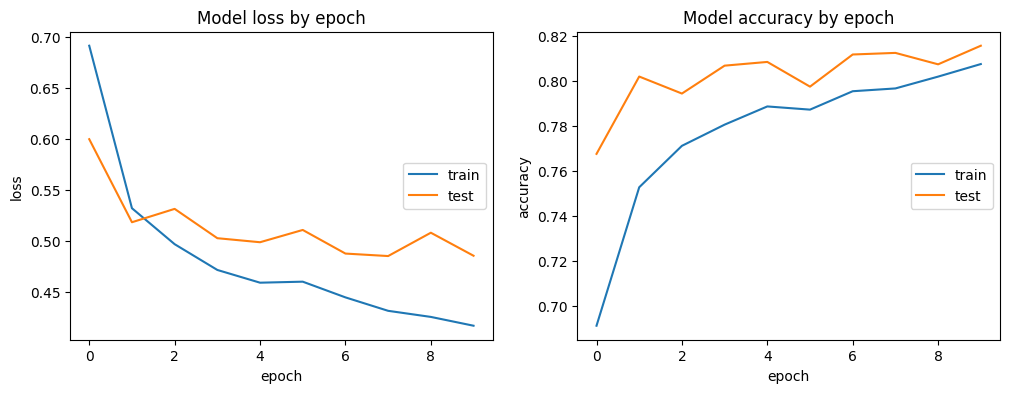

In [29]:
from helper import plot_learning_curve
plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [30]:
from tensorflow import keras
vgg16 = keras.models.load_model(model_name)

In [31]:
from helper import get_predictions_and_labels
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = get_predictions_and_labels(vgg16, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.815154,0.667348,0.968281,0.733883,0.803854,0.626735,1467.000000
Lung_Opacity,0.769201,0.827658,0.901288,0.797359,0.863688,0.740465,2408.000000
Normal,0.851603,0.846762,0.864932,0.849176,0.855799,0.731061,4046.000000
Viral Pneumonia,0.777266,0.928440,0.981694,0.846154,0.954696,0.906591,545.000000
avg_pre,0.817064,0.817064,0.817064,0.817064,0.817064,0.817064,0.817064
avg_rec,0.815497,0.815497,0.815497,0.815497,0.815497,0.815497,0.815497
avg_spe,0.900698,0.900698,0.900698,0.900698,0.900698,0.900698,0.900698
avg_f1,0.814265,0.814265,0.814265,0.814265,0.814265,0.814265,0.814265
avg_geo,0.855408,0.855408,0.855408,0.855408,0.855408,0.855408,0.855408
avg_iba,0.726958,0.726958,0.726958,0.726958,0.726958,0.726958,0.726958


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,979,203,277,8
Lung_Opacity,110,1993,299,6
Normal,105,384,3426,131
Viral Pneumonia,7,11,21,506


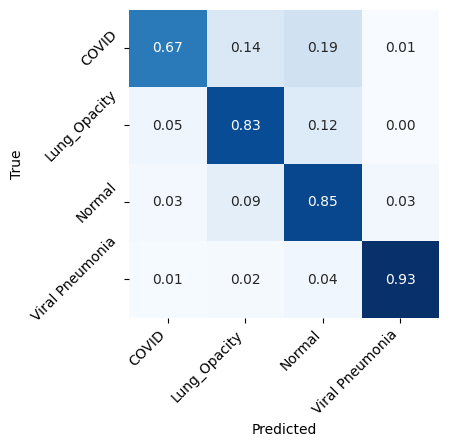

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              979           203     277                8
 Lung_Opacity       110          1993     299                6
 Normal             105           384    3426              131
 Viral Pneumonia      7            11      21              506,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.815154     0.667348     0.968281     0.733883   
 Lung_Opacity        0.769201     0.827658     0.901288     0.797359   
 Normal              0.851603     0.846762     0.864932     0.849176   
 Viral Pneumonia     0.777266     0.928440     0.981694     0.846154   
 avg_pre             0.817064     0.817064     0.817064     0.817064   
 avg_rec             0.815497     0.815497     0.815497     0.815497   
 avg_spe             0.900698     0.900698     0.900698     0.900698   
 avg_f1              0.814265     0.814265     0.814265     0.814265   

In [32]:
from helper import report_model_performance
report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes already not too bad
# However, the recall especially for the covid class is the lowest